In [28]:
# RNN TEXT GENERATION USING TINY SHAKESPEARE
# Student Name : Jeevadharan G
# Roll No      : 24BAD046
# Department   : AI&DS

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import re
import os

print("Libraries imported successfully!")
print("TensorFlow Version:", tf.__version__)
print("NumPy Version:", np.__version__)

Libraries imported successfully!
TensorFlow Version: 2.20.0
NumPy Version: 2.1.3


In [2]:
# ============================================================
# TASK A2 - DOWNLOAD TINY SHAKESPEARE DATASET
# ============================================================

import urllib.request
import os

dataset_url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"

file_path = "/content/tinyshakespeare.txt"

# Download dataset automatically
if not os.path.exists(file_path):
    print("Downloading Tiny Shakespeare dataset...")
    urllib.request.urlretrieve(dataset_url, file_path)
    print("Dataset downloaded successfully!")
else:
    print("Dataset already exists!")

print("File location:", file_path)
print("File size:", os.path.getsize(file_path), "bytes")

Dataset downloaded successfully!
File location: /content/tinyshakespeare.txt
File size: 1115394 bytes


In [3]:
# ============================================================
# TASK A3 - LOAD DATASET
# ============================================================

with open(file_path, "r", encoding="utf-8") as file:
    text = file.read()

print("Dataset loaded successfully!")
print("Total characters:", len(text))

print("\nFirst 1000 characters:")
print(text[:1000])

Dataset loaded successfully!
Total characters: 1115394

First 1000 characters:
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor citizens, the patricians good.
What authority surfeits on would relieve us: if they
would yield us but the superfluity, while it were
wholesome, we might guess they relieved us humanely;
but they think we are too dear: the leanness that
afflicts us, the object of our misery, is as an
inventory to particularise their abundance; our
sufferance is a gain to them Let us revenge this with
our pikes, ere we become rakes: f

In [4]:
# ============================================================
# TASK A4 - EXPLORE DATASET
# ============================================================

print("Dataset Information")
print("-------------------")

print("Number of characters:", len(text))

print("\nFirst 500 characters:")
print(text[:500])

print("\nLast 500 characters:")
print(text[-500:])

Dataset Information
-------------------
Number of characters: 1115394

First 500 characters:
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor

Last 500 characters:
ldst be: the occasion speaks thee, and
My strong imagination sees a crown
Dropping upon thy head.

SEBASTIAN:
What, art thou waking?

ANTONIO:
Do you not hear me speak?

SEBASTIAN:
I do; and surely
It is a sleepy language and thou speak'st
Out of thy sleep. What is it thou didst say?
This is a strange repose, to be asleep
With eyes wide open; standing, speaking, moving,
And yet so 

In [5]:
# ============================================================
# TASK A5 - LOWERCASE CONVERSION
# ============================================================

text = text.lower()

print("Text converted to lowercase successfully!")

print("\nFirst 500 characters:")
print(text[:500])

Text converted to lowercase successfully!

First 500 characters:
first citizen:
before we proceed any further, hear me speak.

all:
speak, speak.

first citizen:
you are all resolved rather to die than to famish?

all:
resolved. resolved.

first citizen:
first, you know caius marcius is chief enemy to the people.

all:
we know't, we know't.

first citizen:
let us kill him, and we'll have corn at our own price.
is't a verdict?

all:
no more talking on't; let it be done: away, away!

second citizen:
one word, good citizens.

first citizen:
we are accounted poor


In [6]:
# ============================================================
# TASK A6 - TOKENIZATION
# ============================================================

# Word-level tokenization
tokens = re.findall(r"\b[a-zA-Z']+\b|[.,!?;:]", text)

print("Tokenization completed!")

print("Total number of tokens:", len(tokens))

print("\nFirst 100 tokens:")
print(tokens[:100])

Tokenization completed!
Total number of tokens: 250145

First 100 tokens:
['first', 'citizen', ':', 'before', 'we', 'proceed', 'any', 'further', ',', 'hear', 'me', 'speak', '.', 'all', ':', 'speak', ',', 'speak', '.', 'first', 'citizen', ':', 'you', 'are', 'all', 'resolved', 'rather', 'to', 'die', 'than', 'to', 'famish', '?', 'all', ':', 'resolved', '.', 'resolved', '.', 'first', 'citizen', ':', 'first', ',', 'you', 'know', 'caius', 'marcius', 'is', 'chief', 'enemy', 'to', 'the', 'people', '.', 'all', ':', 'we', "know't", ',', 'we', "know't", '.', 'first', 'citizen', ':', 'let', 'us', 'kill', 'him', ',', 'and', "we'll", 'have', 'corn', 'at', 'our', 'own', 'price', '.', "is't", 'a', 'verdict', '?', 'all', ':', 'no', 'more', 'talking', "on't", ';', 'let', 'it', 'be', 'done', ':', 'away', ',', 'away', '!']


In [7]:
# ============================================================
# TASK A7 - BUILD VOCABULARY
# ============================================================

vocab = sorted(set(tokens))

print("Vocabulary created successfully!")

print("Vocabulary size:", len(vocab))

print("\nFirst 100 vocabulary items:")
print(vocab[:100])

Vocabulary created successfully!
Vocabulary size: 12379

First 100 vocabulary items:
['!', ',', '.', ':', ';', '?', 'a', "abandon'd", 'abase', 'abate', 'abated', 'abbey', 'abbot', 'abed', "abel's", 'abet', 'abhor', "abhorr'd", 'abhorred', 'abhorring', 'abhors', 'abhorson', 'abide', 'abides', 'abilities', 'ability', "ability's", 'abject', 'abjects', 'abjured', 'able', 'aboard', 'abode', 'abodements', 'aboding', 'abominable', 'abortive', 'abound', "abound'st", 'about', 'above', 'abraham', "abraham's", 'abreast', 'abroach', 'abroad', 'absence', 'absent', 'absolute', 'absolutely', 'absolved', 'absolver', 'abstains', 'abstinence', 'abstract', 'abundance', 'abundant', 'abundantly', 'abuse', 'abused', 'abuses', 'abusing', 'abysm', 'accent', 'accents', 'accept', 'acceptance', 'access', 'accessary', 'accident', 'accidental', 'accidentally', 'accidents', 'acclamations', 'accommodations', 'accompanied', 'accompany', 'accomplish', "accomplish'd", 'accomplished', 'accompt', 'accord', 'according', '

In [8]:
# ============================================================
# TASK A8 - WORD TO INTEGER INDEX
# ============================================================

# Word -> Integer
word_to_index = {}

# Reserve 0 for padding
word_to_index["<PAD>"] = 0

for i, word in enumerate(vocab):
    word_to_index[word] = i + 1

# Integer -> Word
index_to_word = {}

for word, index in word_to_index.items():
    index_to_word[index] = word

print("Word indexing completed!")

print("\nSample word-to-index mapping:")

for word in list(word_to_index.keys())[:30]:
    print(word, ":", word_to_index[word])

print("\nTotal vocabulary size:", len(word_to_index))

Word indexing completed!

Sample word-to-index mapping:
<PAD> : 0
! : 1
, : 2
. : 3
: : 4
; : 5
? : 6
a : 7
abandon'd : 8
abase : 9
abate : 10
abated : 11
abbey : 12
abbot : 13
abed : 14
abel's : 15
abet : 16
abhor : 17
abhorr'd : 18
abhorred : 19
abhorring : 20
abhors : 21
abhorson : 22
abide : 23
abides : 24
abilities : 25
ability : 26
ability's : 27
abject : 28
abjects : 29

Total vocabulary size: 12380


In [9]:
# ============================================================
# TASK A9 - NUMERICAL REPRESENTATION
# ============================================================

encoded_text = []

for token in tokens:
    encoded_text.append(word_to_index[token])

print("Text converted into numerical representation!")

print("\nFirst 30 words:")
print(tokens[:30])

print("\nFirst 30 numerical values:")
print(encoded_text[:30])

Text converted into numerical representation!

First 30 words:
['first', 'citizen', ':', 'before', 'we', 'proceed', 'any', 'further', ',', 'hear', 'me', 'speak', '.', 'all', ':', 'speak', ',', 'speak', '.', 'first', 'citizen', ':', 'you', 'are', 'all', 'resolved', 'rather', 'to', 'die', 'than']

First 30 numerical values:
[4086, 1886, 4, 901, 11914, 8210, 438, 4470, 2, 5049, 6609, 9953, 3, 302, 4, 9953, 2, 9953, 3, 4086, 1886, 4, 12355, 516, 302, 8832, 8548, 10950, 2979, 10751]


In [10]:
# ============================================================
# TASK A10 - CREATE INPUT SEQUENCES
# ============================================================

sequence_length = 20

input_sequences = []

for i in range(sequence_length, len(encoded_text)):

    sequence = encoded_text[i-sequence_length:i+1]

    input_sequences.append(sequence)

input_sequences = np.array(
    input_sequences,
    dtype=np.int32
)

print("Input sequences created!")

print("Sequence length:", sequence_length)
print("Total sequences:", len(input_sequences))

print("\nShape of input sequences:")
print(input_sequences.shape)

Input sequences created!
Sequence length: 20
Total sequences: 250125

Shape of input sequences:
(250125, 21)


In [11]:
# ============================================================
# TASK A11 - INPUT X AND TARGET y
# ============================================================

# First 20 words = input
X = input_sequences[:, :-1]

# 21st word = target
y = input_sequences[:, -1]

print("Input and target separated successfully!")

print("\nX shape:", X.shape)
print("y shape:", y.shape)

print("\nFirst input sequence:")
print(X[0])

print("\nFirst target:")
print(y[0])

Input and target separated successfully!

X shape: (250125, 20)
y shape: (250125,)

First input sequence:
[ 4086  1886     4   901 11914  8210   438  4470     2  5049  6609  9953
     3   302     4  9953     2  9953     3  4086]

First target:
1886


In [12]:
# ============================================================
# TASK A12 - DECODE SEQUENCE
# ============================================================

def decode_sequence(sequence):

    words = []

    for index in sequence:

        index = int(index)

        if index != 0:
            words.append(index_to_word[index])

    return " ".join(words)


print("Input sequence:")
print(decode_sequence(X[0]))

print("\nTarget word:")
print(index_to_word[int(y[0])])

Input sequence:
first citizen : before we proceed any further , hear me speak . all : speak , speak . first

Target word:
citizen


In [13]:
# ============================================================
# TASK A13 - TRAIN / VALIDATION SPLIT
# ============================================================

# Limit the number of sequences for faster Colab training
max_sequences = 60000

X = X[:max_sequences]
y = y[:max_sequences]

# 80% training
# 20% validation

split_index = int(0.8 * len(X))

X_train = X[:split_index]
y_train = y[:split_index]

X_val = X[split_index:]
y_val = y[split_index:]

print("Dataset split completed!")

print("\nTraining samples:", len(X_train))
print("Validation samples:", len(X_val))

print("\nX_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("\nX_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)

Dataset split completed!

Training samples: 48000
Validation samples: 12000

X_train shape: (48000, 20)
y_train shape: (48000,)

X_val shape: (12000, 20)
y_val shape: (12000,)


In [14]:
# ============================================================
# TASK B1 - CREATE EMBEDDING + RNN MODEL
# ============================================================

vocab_size = len(word_to_index)

embedding_dim = 128
rnn_units = 128

model = tf.keras.Sequential([

    tf.keras.layers.Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim
    ),

    tf.keras.layers.SimpleRNN(
        rnn_units
    ),

    tf.keras.layers.Dense(
        vocab_size,
        activation="softmax"
    )
])

print("RNN model created successfully!")

RNN model created successfully!


In [15]:
# ============================================================
# TASK B2 - COMPILE MODEL
# ============================================================

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


In [16]:
# ============================================================
# TASK B3 - MODEL SUMMARY
# ============================================================

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Model built successfully!


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 20, 128)        │     1,584,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 12380)          │     1,597,020 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,214,556 (12.26 MB)

 Trainable params: 3,214,556 (12.26 MB)

 Non-trainable params: 0 (0.00 B)

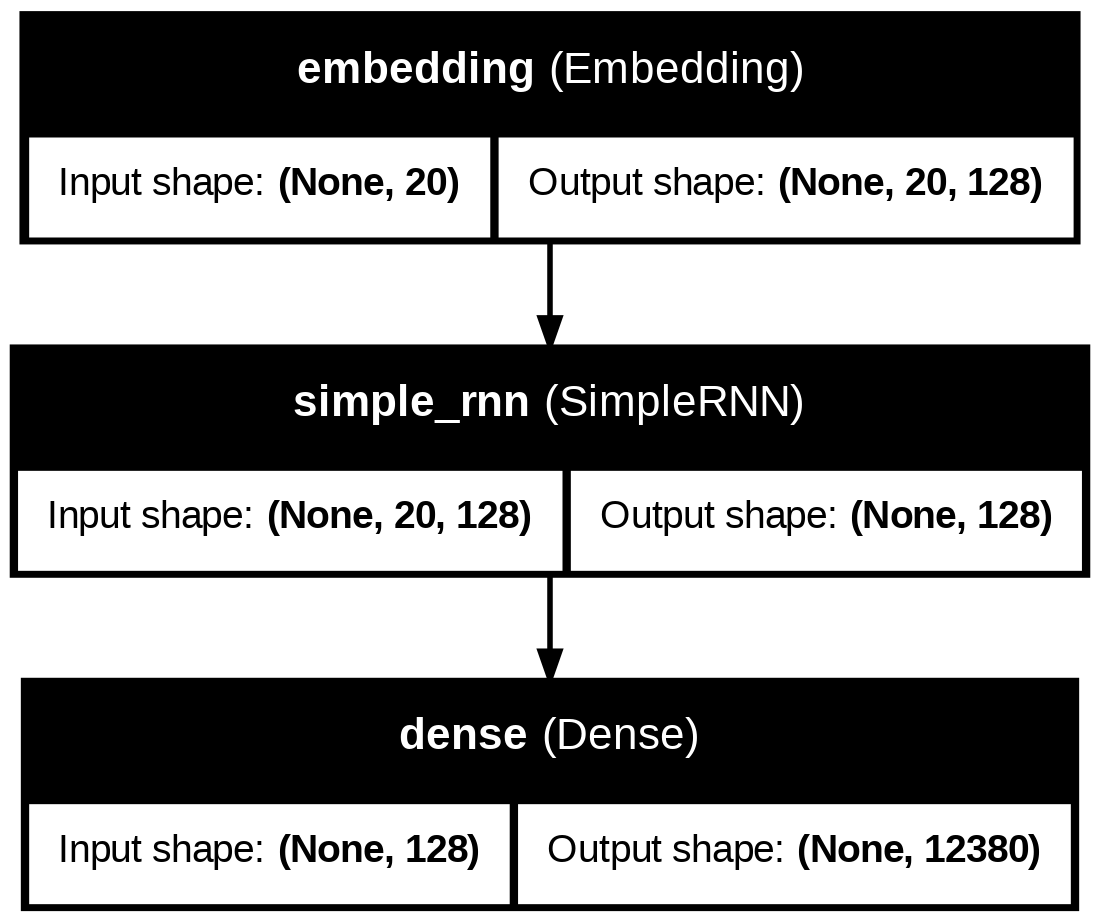

In [17]:
# ============================================================
# TASK B4 - MODEL ARCHITECTURE
# ============================================================

# Build the model explicitly
model.build(input_shape=(None, sequence_length))

print("Model built successfully!")

# Display model summary
model.summary()

# Display architecture
tf.keras.utils.plot_model(
    model,
    show_shapes=True,
    show_layer_names=True
)

In [18]:
# ============================================================
# TASK C1 - TRAIN RNN MODEL
# ============================================================

epochs = 5
batch_size = 128

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    verbose=1
)

print("\nTraining completed successfully!")

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.0745 - loss: 6.6485 - val_accuracy: 0.0803 - val_loss: 6.6312
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.1044 - loss: 5.9476 - val_accuracy: 0.1219 - val_loss: 6.1188
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.1294 - loss: 5.5393 - val_accuracy: 0.1272 - val_loss: 5.9955
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.1430 - loss: 5.2895 - val_accuracy: 0.1365 - val_loss: 5.9044
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1529 - loss: 5.0713 - val_accuracy: 0.1355 - val_loss: 5.8710

Training completed successfully!


In [19]:
# ============================================================
# TASK C2 - TRAINING AND VALIDATION METRICS
# ============================================================

train_loss = history.history["loss"][-1]
train_accuracy = history.history["accuracy"][-1]

val_loss = history.history["val_loss"][-1]
val_accuracy = history.history["val_accuracy"][-1]

print("=" * 50)
print("FINAL MODEL PERFORMANCE")
print("=" * 50)

print("Training Loss      :", round(train_loss, 4))
print("Training Accuracy  :", round(train_accuracy, 4))

print("Validation Loss    :", round(val_loss, 4))
print("Validation Accuracy:", round(val_accuracy, 4))

print("=" * 50)

FINAL MODEL PERFORMANCE
Training Loss      : 5.0713
Training Accuracy  : 0.1529
Validation Loss    : 5.871
Validation Accuracy: 0.1355


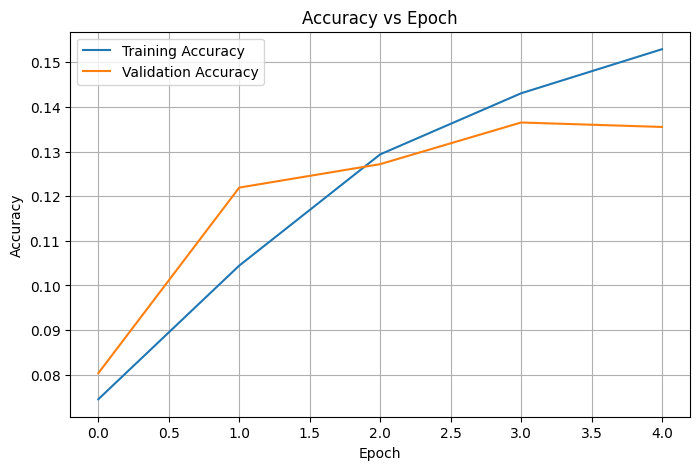

In [20]:
# ============================================================
# TASK C3 - ACCURACY VS EPOCH
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.grid()

plt.show()

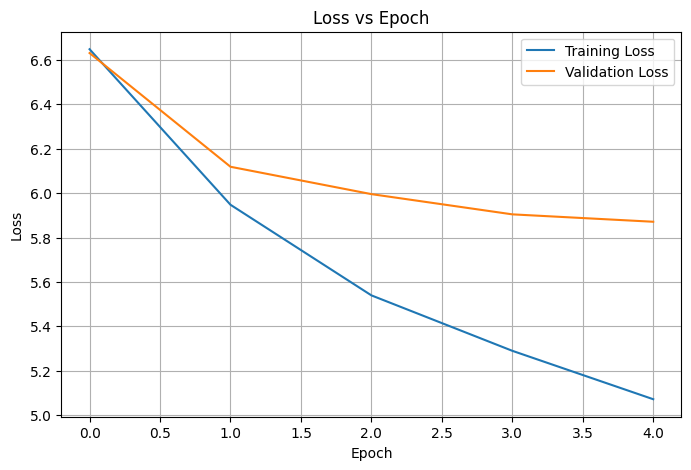

In [21]:
# ============================================================
# TASK C4 - LOSS VS EPOCH
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid()

plt.show()

In [22]:
# ============================================================
# TASK D1 - TEXT GENERATION FUNCTION
# ============================================================

def generate_text(seed_text, num_words=30):

    generated_text = seed_text.lower()

    for _ in range(num_words):

        # Tokenize current text
        current_tokens = re.findall(
            r"\b[a-zA-Z']+\b|[.,!?;:]",
            generated_text
        )

        # Convert words to numbers
        encoded = []

        for word in current_tokens:

            if word in word_to_index:
                encoded.append(word_to_index[word])

        # Take last 20 tokens
        encoded = encoded[-sequence_length:]

        # Padding
        if len(encoded) < sequence_length:

            encoded = (
                [0] * (sequence_length - len(encoded))
                + encoded
            )

        # Convert to NumPy
        input_data = np.array(
            [encoded],
            dtype=np.int32
        )

        # Predict next word
        prediction = model.predict(
            input_data,
            verbose=0
        )[0]

        # Get highest probability word
        predicted_index = np.argmax(prediction)

        predicted_word = index_to_word[predicted_index]

        # Skip padding
        if predicted_word == "<PAD>":
            continue

        # Add predicted word
        generated_text += " " + predicted_word

    return generated_text


print("Text generation function created successfully!")

Text generation function created successfully!


In [23]:
# ============================================================
# TASK D2 - SINGLE SEED TEXT GENERATION
# ============================================================

seed = "to be"

generated = generate_text(
    seed,
    num_words=30
)

print("Seed Input:")
print(seed)

print("\nGenerated Text:")
print(generated)

Seed Input:
to be

Generated Text:
to be . coriolanus : i , i have not to the people , and i will not the people , and i will not the people , and i will not


In [24]:
# ============================================================
# TASK D3 - MULTIPLE SEED INPUTS
# ============================================================

seed_inputs = [
    "to be",
    "the king",
    "my lord",
    "what is",
    "fair prince"
]

for seed in seed_inputs:

    print("=" * 70)

    print("Seed Input:")
    print(seed)

    print("\nGenerated Text:")

    generated = generate_text(
        seed,
        num_words=30
    )

    print(generated)

    print()

Seed Input:
to be

Generated Text:
to be . coriolanus : i , i have not to the people , and i will not the people , and i will not the people , and i will not

Seed Input:
the king

Generated Text:
the king . coriolanus : i , i have not in the people , and i will not the people , and i will not the people , and i will not

Seed Input:
my lord

Generated Text:
my lord . coriolanus : i , i have not in the people , and i will not the people , and i will not the people , and i will not

Seed Input:
what is

Generated Text:
what is the people , and i will not the people , and i will not the people , and i will not the people , and i will not the people

Seed Input:
fair prince

Generated Text:
fair prince . first murderer : i , i have not in the people , and i will not the people , and i will not the people , and i will



In [25]:
# ============================================================
# TASK D4 - TEXT GENERATION COMPARISON
# ============================================================

seed_inputs = [
    "to be or",
    "the king",
    "my lord"
]

for seed in seed_inputs:

    print("\n" + "=" * 80)

    print("SEED:", seed)

    print("=" * 80)

    result = generate_text(
        seed,
        num_words=40
    )

    print(result)


SEED: to be or
to be or . coriolanus : i , i have not in the people , and i will not the people , and i will not the people , and i will not the people , and i will not the people ,

SEED: the king
the king . coriolanus : i , i have not in the people , and i will not the people , and i will not the people , and i will not the people , and i will not the people ,

SEED: my lord
my lord . coriolanus : i , i have not in the people , and i will not the people , and i will not the people , and i will not the people , and i will not the people ,


In [26]:
# ============================================================
# TASK D5 - OBSERVATION
# ============================================================

print("""
OBSERVATION:

The Simple RNN learned sequential patterns from the
Tiny Shakespeare dataset.

The model predicts the next word based on the previous
20 words in the sequence.

Different seed inputs generated different text samples.

Some generated text was meaningful and contextually
relevant, while some outputs contained grammatical
errors or repeated words.

This shows that the RNN can learn sequential patterns
but a Simple RNN has limitations in remembering
long-term dependencies.
""")


OBSERVATION:

The Simple RNN learned sequential patterns from the
Tiny Shakespeare dataset.

The model predicts the next word based on the previous
20 words in the sequence.

Different seed inputs generated different text samples.

Some generated text was meaningful and contextually
relevant, while some outputs contained grammatical
errors or repeated words.

This shows that the RNN can learn sequential patterns
but a Simple RNN has limitations in remembering
long-term dependencies.



In [29]:
# ============================================================
# FINAL RESULT
# ============================================================

print("=" * 60)
print("RNN TEXT GENERATION - FINAL RESULT")
print("=" * 60)

print("Student Name :", "jeevadharan G.")
print("Roll No      :", "24BAD046")
print("Department   :", "AI & DS")

print("\nDataset      :", "Tiny Shakespeare")
print("Model        :", "Simple RNN")
print("Embedding    :", embedding_dim)
print("RNN Units    :", rnn_units)
print("Sequence Len :", sequence_length)
print("Optimizer    :", "Adam")
print("Epochs       :", epochs)

print("\n--- PERFORMANCE ---")

print("Training Accuracy   :", round(train_accuracy, 4))
print("Validation Accuracy :", round(val_accuracy, 4))

print("Training Loss       :", round(train_loss, 4))
print("Validation Loss     :", round(val_loss, 4))

print("\n--- GENERATED TEXT ---")

print(generate_text(
    "to be or",
    num_words=40
))

print("\n" + "=" * 60)
print("EXPERIMENT COMPLETED SUCCESSFULLY!")
print("=" * 60)

RNN TEXT GENERATION - FINAL RESULT
Student Name : jeevadharan G.
Roll No      : 24BAD046
Department   : AI & DS

Dataset      : Tiny Shakespeare
Model        : Simple RNN
Embedding    : 128
RNN Units    : 128
Sequence Len : 20
Optimizer    : Adam
Epochs       : 5

--- PERFORMANCE ---
Training Accuracy   : 0.1529
Validation Accuracy : 0.1355
Training Loss       : 5.0713
Validation Loss     : 5.871

--- GENERATED TEXT ---
to be or . coriolanus : i , i have not in the people , and i will not the people , and i will not the people , and i will not the people , and i will not the people ,

EXPERIMENT COMPLETED SUCCESSFULLY!
